Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

Reading in and preprocess data

In [18]:
data = pd.read_excel('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/psp/notebooks/reviews/KOLFvsUsluer.xlsx')
data

,Usluer et al. KOLF Gene Name,Usluer et al. KOLF L2FC,This Work KOLF Gene Name,This Work KOLF L2FC
0,SAMD11,-0.119366,TADA2B,5.2100
1,NOC2L,-4.183151,EIF2AK4,4.4689
2,KLHL17,-0.755619,SUPT20H,3.8163
3,PLEKHN1,-0.069869,TP53,3.6483
4,PERM1,0.156312,BBC3,3.3506
...,...,...,...,...
18553,HGC6.3,-0.638449,NaN,NaN
18554,TAS2R19,0.254248,NaN,NaN
18555,BPY2,0.096037,NaN,NaN
18556,SPIN2A,-1.953862,NaN,NaN


shape: (18558, 4)
columns: ['Usluer et al. KOLF Gene Name', 'Usluer et al. KOLF L2FC', 'This Work KOLF Gene Name', 'This Work KOLF L2FC']
Selected columns:
  This Work gene: This Work KOLF Gene Name
  This Work L2FC: This Work KOLF L2FC
  Usluer gene: Usluer et al. KOLF Gene Name
  Usluer L2FC: Usluer et al. KOLF L2FC
Label genes found: ['BAK1', 'PTEN', 'TP53']
Call counts: {'Not called': 9552, 'Fitness enriching': 14, 'Essential (moderate)': 804, 'Essential (strong)': 498}
pearson_r 0.712581597407456
pearson_p 0.0
spearman_r 0.5122296417954949
spearman_p 0.0


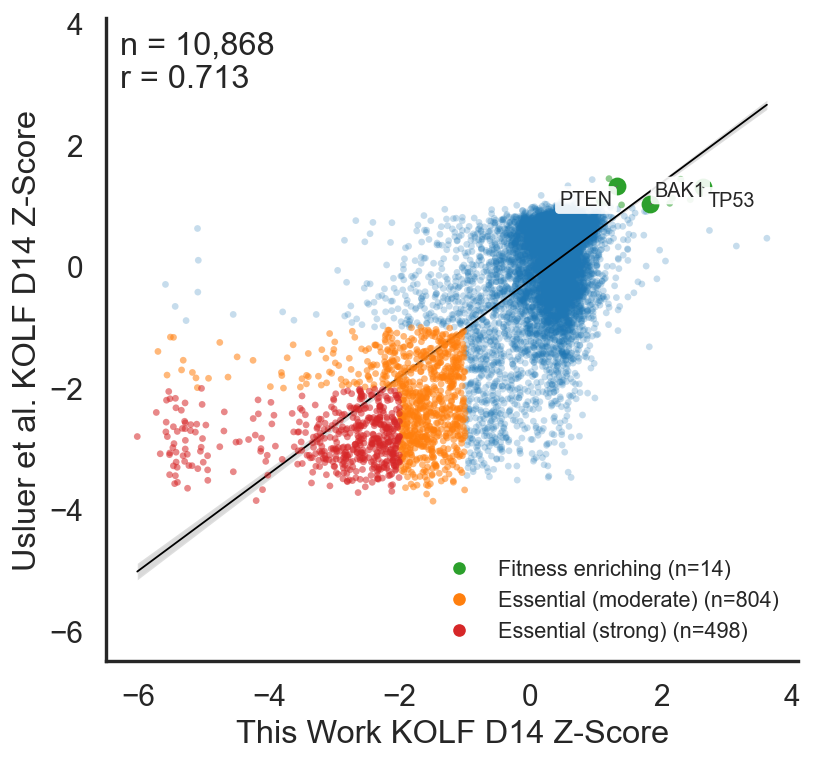

Aligned genes: 10868


In [26]:
# --- Z-scored correlation: This Work KOLF vs Usluer KOLF (pub-ready + labeled shared hits) ---

# Style (close to your earlier regplot look, but cleaner for pub)
sns.set_theme(style='white', context='talk')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['savefig.dpi'] = 300

print('shape:', data.shape)
print('columns:', list(data.columns))

cols = list(data.columns)

def _norm(s: str) -> str:
    s = str(s).lower()
    out = []
    for ch in s:
        out.append(ch if ch.isalnum() else ' ')
    return ' '.join(''.join(out).split())

_norm_cols = {_c: _norm(_c) for _c in cols}

def _find_col(*, must=(), any_=(), forbid=()):
    hits = []
    for c, cl in _norm_cols.items():
        if any(f in cl for f in forbid):
            continue
        if not all(m in cl for m in must):
            continue
        if any_ and not any(a in cl for a in any_):
            continue
        hits.append(c)
    if len(hits) == 1:
        return hits[0]
    if len(hits) == 0:
        return None
    hits_sorted = sorted(hits, key=lambda c: (len(_norm_cols[c]), str(c)))
    return hits_sorted[0]

def _prep_dataset(df, gene_col, l2fc_col, *, l2fc_name):
    out = df[[gene_col, l2fc_col]].copy()
    out = out.rename(columns={gene_col: 'gene', l2fc_col: l2fc_name})
    out['gene'] = out['gene'].astype(str).str.strip().str.upper()
    out[l2fc_name] = pd.to_numeric(out[l2fc_name], errors='coerce')
    out = out.dropna(subset=['gene', l2fc_name])
    out = out.groupby('gene', as_index=False)[[l2fc_name]].mean()
    mu = out[l2fc_name].mean()
    sd = out[l2fc_name].std(ddof=0)
    if sd == 0 or np.isnan(sd):
        raise ValueError(f"Std dev is zero/NaN for {l2fc_name}; can't z-score.")
    out[l2fc_name + '_z'] = (out[l2fc_name] - mu) / sd
    return out

# ---- Find the KOLF columns (robust to minor header tweaks)
usluer_gene = _find_col(must=('usluer', 'kolf', 'gene'), any_=('name', 'symbol'))
usluer_l2fc = _find_col(must=('usluer', 'kolf'), any_=('l2fc', 'log2fc', 'log2'))
this_gene = _find_col(must=('this', 'work', 'kolf', 'gene'), any_=('name', 'symbol'))
this_l2fc = _find_col(must=('this', 'work', 'kolf'), any_=('l2fc', 'log2fc', 'log2'))

missing = {
    'usluer_gene': usluer_gene,
    'usluer_l2fc': usluer_l2fc,
    'this_gene': this_gene,
    'this_l2fc': this_l2fc,
}
not_found = [k for k, v in missing.items() if v is None]
if not_found:
    raise ValueError(
        "Missing required columns: " + ", ".join(not_found) +
        "\n\nDetected columns:\n- " + "\n- ".join(map(str, cols))
    )

print('Selected columns:')
print('  This Work gene:', this_gene)
print('  This Work L2FC:', this_l2fc)
print('  Usluer gene:', usluer_gene)
print('  Usluer L2FC:', usluer_l2fc)

# ---- Build aligned z-score table
this_df = _prep_dataset(data, this_gene, this_l2fc, l2fc_name='this_l2fc')
usluer_df = _prep_dataset(data, usluer_gene, usluer_l2fc, l2fc_name='usluer_l2fc')

aligned = pd.merge(
    this_df[['gene', 'this_l2fc_z']],
    usluer_df[['gene', 'usluer_l2fc_z']],
    on='gene',
    how='inner',
)

# Correlations
pearson_r, pearson_p = stats.pearsonr(aligned['this_l2fc_z'], aligned['usluer_l2fc_z'])
spearman_r, spearman_p = stats.spearmanr(aligned['this_l2fc_z'], aligned['usluer_l2fc_z'])

# ---- Color ALL genes by your threshold-based categories; label selected genes
# Rules are applied only when BOTH datasets meet the threshold.
# Priority: essential strong (< -2) > essential moderate (< -1) > fitness enriching (> 1)

from matplotlib.lines import Line2D

aligned = aligned.copy()

aligned['call'] = 'Not called'
aligned.loc[(aligned['this_l2fc_z'] > 1) & (aligned['usluer_l2fc_z'] > 1), 'call'] = 'Fitness enriching'
aligned.loc[(aligned['this_l2fc_z'] < -1) & (aligned['usluer_l2fc_z'] < -1), 'call'] = 'Essential (moderate)'
# strong overrides moderate
aligned.loc[(aligned['this_l2fc_z'] < -2) & (aligned['usluer_l2fc_z'] < -2), 'call'] = 'Essential (strong)'

palette = {
    'Fitness enriching': '#2ca02c',
    'Essential (moderate)': '#ff7f0e',
    'Essential (strong)': '#d62728',
    'Not called': '#1f77b4',
}

# Genes to label
label_genes = ['BAK1', 'TP53', 'PTEN']
lab = aligned[aligned['gene'].isin(label_genes)].copy()
print('Label genes found:', lab['gene'].tolist())

# ---- Plot
fig, ax = plt.subplots(figsize=(6.6, 6.2))

# Scatter by category (so we can color points)
order = ['Not called', 'Fitness enriching', 'Essential (moderate)', 'Essential (strong)']
call_counts = aligned['call'].value_counts().to_dict()
print('Call counts:', {k: int(call_counts.get(k, 0)) for k in order})

for cat in order:
    dfc = aligned[aligned['call'] == cat]
    if dfc.empty:
        continue
    ax.scatter(
        dfc['this_l2fc_z'],
        dfc['usluer_l2fc_z'],
        s=14,
        alpha=0.25 if cat == 'Not called' else 0.55,
        c=palette[cat],
        edgecolors='none',
        # don't put Not called in legend
        label=None if cat == 'Not called' else cat,
        zorder=2 if cat == 'Not called' else 3,
    )

# Regression line (without re-drawing scatter)
sns.regplot(
    data=aligned,
    x='this_l2fc_z',
    y='usluer_l2fc_z',
    scatter=False,
    line_kws=dict(color='black', linewidth=1),
    ax=ax,
)

lims = [
    np.nanmin([ax.get_xlim()[0], ax.get_ylim()[0]]),
    np.nanmax([ax.get_xlim()[1], ax.get_ylim()[1]]),
]
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel('This Work KOLF D14 Z-Score')
ax.set_ylabel('Usluer et al. KOLF D14 Z-Score')

print('pearson_r', pearson_r)
print('pearson_p', pearson_p)
print('spearman_r', spearman_r)
print('spearman_p', spearman_p)

ax.text(
    0.02, 0.98,
    f"n = {len(aligned):,}\nr = {pearson_r:.3f}",
    transform=ax.transAxes,
    va='top',
    ha='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.90, linewidth=0.6),
)

# Label selected genes (and color their points by the same call)
for i, row in lab.reset_index(drop=True).iterrows():
    x = row['this_l2fc_z']
    y = row['usluer_l2fc_z']
    gene = row['gene']
    cat = row['call']

    ax.scatter([x], [y], s=70, color=palette.get(cat, '0.25'), zorder=6)

    dx = 0.07 if i % 2 == 0 else -0.07
    dy = 0.07 if i % 3 == 0 else -0.07
    ax.annotate(
        gene,
        (x, y),
        xytext=(x + dx, y + dy),
        textcoords='data',
        fontsize=11,
        ha='left' if dx > 0 else 'right',
        va='bottom' if dy > 0 else 'top',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.90, linewidth=0.4),
        arrowprops=dict(arrowstyle='-', color='0.4', linewidth=0.6, shrinkA=0, shrinkB=4),
        zorder=7,
    )

# Legend (exclude Not called; include counts)
legend_order = ['Fitness enriching', 'Essential (moderate)', 'Essential (strong)']
legend_handles = []
legend_labels = []
for c in legend_order:
    n = int(call_counts.get(c, 0))
    if n == 0:
        continue
    legend_handles.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=palette[c], markersize=8))
    legend_labels.append(f"{c} (n={n:,})")

if legend_handles:
    ax.legend(
        handles=legend_handles,
        labels=legend_labels,
        loc='lower right',
        frameon=False,
        framealpha=0.9,
        fontsize=12
    )

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/psp/notebooks/figs/KOLF_vs_Usluer_D14_zscore_comparison.svg')
plt.show()

# Keep for downstream inspection
aligned_kolf = aligned
print('Aligned genes:', aligned_kolf.shape[0])

Essential (strong) counts (within aligned genes):
  This Work: 675
  Usluer: 1246
  Overlap: 498


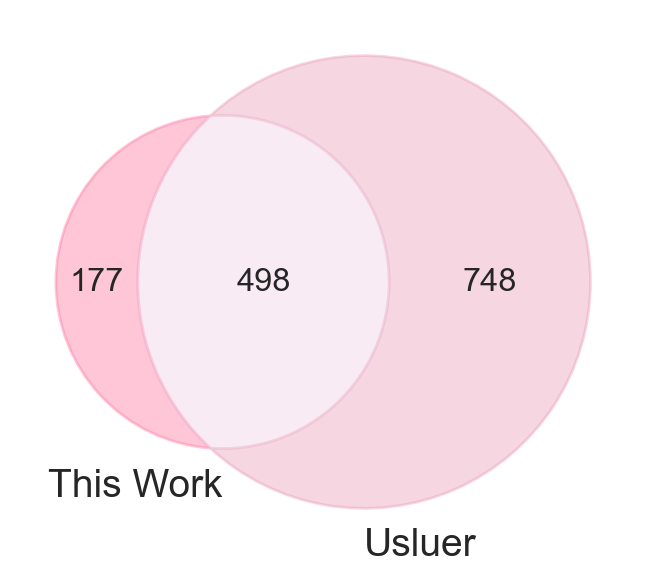

In [45]:
# --- Venn diagram: Essential (strong) genes (z < -2) ---

# Requires Cell 4 to have been run (so aligned_kolf exists)
if 'aligned_kolf' not in globals():
    raise RuntimeError('Run the KOLF z-score comparison cell first (it creates aligned_kolf).')

# Define strong sets within the shared (aligned) gene universe
this_strong = set(aligned_kolf.loc[aligned_kolf['this_l2fc_z'] < -2, 'gene'])
usluer_strong = set(aligned_kolf.loc[aligned_kolf['usluer_l2fc_z'] < -2, 'gene'])

both = this_strong & usluer_strong

print('Essential (strong) counts (within aligned genes):')
print('  This Work:', len(this_strong))
print('  Usluer:', len(usluer_strong))
print('  Overlap:', len(both))

# Plot Venn
try:
    from matplotlib_venn import venn2

    plt.figure(figsize=(5.8, 4.8))
    v = venn2([this_strong, usluer_strong], set_labels=('This Work', 'Usluer'))
    v.get_patch_by_id('10').set_color('#FF729F')   # This Work only
    v.get_patch_by_id('01').set_color('#EA9AB2')   # Usluer only
    v.get_patch_by_id('11').set_color('#EFCFE3')   # Overlap
    plt.tight_layout()
    plt.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/psp/notebooks/figs/KOLF_vs_Usluer_D14_strong_venn.svg')
    plt.show()
except Exception as e:
    # Fallback if matplotlib-venn isn't installed
    import matplotlib.patches as patches

    print('Note: matplotlib_venn not available; showing a simple 2-circle overlap instead.')
    print('Error:', repr(e))

    only_this = len(this_strong - usluer_strong)
    only_usluer = len(usluer_strong - this_strong)

    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    ax.add_patch(patches.Circle((0.45, 0.5), 0.30, alpha=0.35, color='#A3B9C9'))
    ax.add_patch(patches.Circle((0.65, 0.5), 0.30, alpha=0.35, color='#A09CB0'))

    ax.text(0.35, 0.5, str(only_this), ha='center', va='center', fontsize=14)
    ax.text(0.55, 0.5, str(len(both)), ha='center', va='center', fontsize=14)
    ax.text(0.75, 0.5, str(only_usluer), ha='center', va='center', fontsize=14)

    ax.text(0.33, 0.82, 'This Work', ha='center', va='center')
    ax.text(0.77, 0.82, 'Usluer', ha='center', va='center')

    ax.set_title('Essential (strong) genes (z < -2)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Optional: list overlapping genes
# display(sorted(both))

In [44]:
for gene in both:\
    print(gene)

FAM32A
NUP98
PSMG3
POLD3
MRPL9
MRPS10
POLR3K
ANAPC2
BTF3
URM1
FXN
NIFK
RPS23
MED18
RRP12
EIF2B4
CDC123
MRPL41
LAS1L
SRP19
DHRS1
POLA2
GTF2F2
HNRNPL
RPS3A
PWP1
CDK12
PSMB7
ACTR10
CSTF3
GFM1
CLNS1A
NVL
MOSPD2
PDCD7
TIMELESS
SNUPN
ACTL6A
RRN3
POLD1
PPIE
ELP4
NUP62
CCT7
EIF1AX
PPAN
RPAP1
RCL1
URB1
PNN
TRMT6
ANAPC4
RPL37
RNPC3
DGCR8
IMP3
TUBG1
GRWD1
EXOC2
BRF1
GPATCH1
NOL6
CCT4
EIF6
PSMB3
VCP
CDK1
DCTN3
RPS4X
RPS7
SNRNP25
RPL26
ASCC3
TUBGCP3
GOLT1B
TIPRL
ZCRB1
GAR1
ATP6V1C1
NOB1
RPL38
TPRKB
SKA1
ARCN1
RPP30
INTS5
KIF18A
NUFIP1
TRAPPC3
SMU1
CINP
SNAP23
RPAP3
CCDC86
PRPF3
EIF3M
MRPL16
CENPM
MRPS33
CENPI
PPP1R15B
PSMC1
SF3B4
IARS2
RFC5
C5ORF22
NUP160
YTHDC1
USP37
GEMIN5
SYMPK
LRRC57
VRTN
COG8
POP1
RPL31
DNA2
TAF1A
GET4
NEDD8
OPA1
DR1
NEFL
TUBA1B
RPL10
NUDCD3
COQ4
HAUS3
RPS13
CDC42
CNTROB
MNAT1
TBCD
SYF2
PI4KA
RRP9
CCT8
TCP1
TBL3
WDR12
DCTN6
EXOSC10
SOD1
RANBP2
RPS27A
PPWD1
GLRX3
HNRNPC
SNRPC
ZWINT
CDC6
GPKOW
PRIM2
GINS1
RPA2
FDPS
RPL23A
TRAIP
EXOSC1
VBP1
SEC62
LAGE3
EEF1G
DTL
WDR3
RPS6
MCM9
RP